C:\Users\njy60\anaconda3\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[-3.9568443]
 [-2.977795 ]]


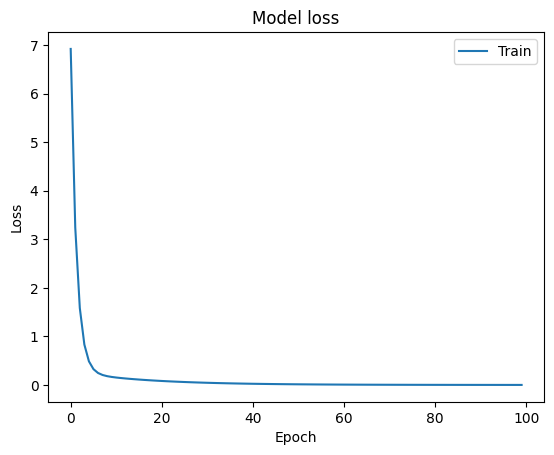

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# y = -1 * x + 1
x_train = np.array([1, 2, 3, 4], dtype=float)
y_train = np.array([0, -1, -2, -3], dtype=float)

# y = W·x + b
    # units=1: 출력 노드 1개 → 결과값 하나
    # input_dim=1: 입력 x가 1차원 스칼라
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=1, input_dim=1))

# Loss = MSE
# Optimizer = SGD (모델이 W, b 값을 조금씩 조정하며 loss를 줄인다.)
    # learning_rate=0.1: 한 번 업데이트할 때 이동량
    #너무 크면 발산, 너무 작으면 학습 느림
sgd = tf.keras.optimizers.SGD(learning_rate=0.1)
model.compile(loss='mse', optimizer=sgd)

# epoch=100: 데이터를 100번 반복 학습
# history.history['loss']: 매 epoch마다의 loss 기록
history = model.fit(x_train, y_train, epochs=100, verbose=0)

# 학습된 모델이 x=5,4일 때 y를 어떻게 예측하는지 확인.
# 대략 [-4, -3] 근처가 나오면 학습 성공
y_predict = model.predict(np.array([5, 4]))
print(y_predict)

# Loss가 줄어들고 있으면 학습이 잘된 것.
    # learning rate 문제, 데이터 문제, 모델 구조 문제
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'])
plt.show()
